In [3]:
import pandas as pd

# run this command in terminal first: pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# run this command in terminal first: pip install pandas scikit-learn xgboost
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [4]:
df = pd.read_csv('cleaned_yrbs_data.csv')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15694 entries, 0 to 15693
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         15694 non-null  float64
 1   gender                      15694 non-null  str    
 2   education_level             15694 non-null  str    
 3   ride_drinking_driver        15694 non-null  float64
 4   school_safety_concern       15694 non-null  float64
 5   threatened_at_school        15694 non-null  float64
 6   fight_count                 15694 non-null  float64
 7   school_fight_count          15694 non-null  float64
 8   neighborhood_violence       15694 non-null  float64
 9   sexual_violence             15694 non-null  float64
 10  school_racism               15694 non-null  float64
 11  school_bullying             15694 non-null  float64
 12  cyber_bullying              15694 non-null  float64
 13  feel_hopeless               15694 non-null

C:\Users\Norawit\AppData\Local\Temp\ipykernel_28580\3488811937.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include='object').columns:


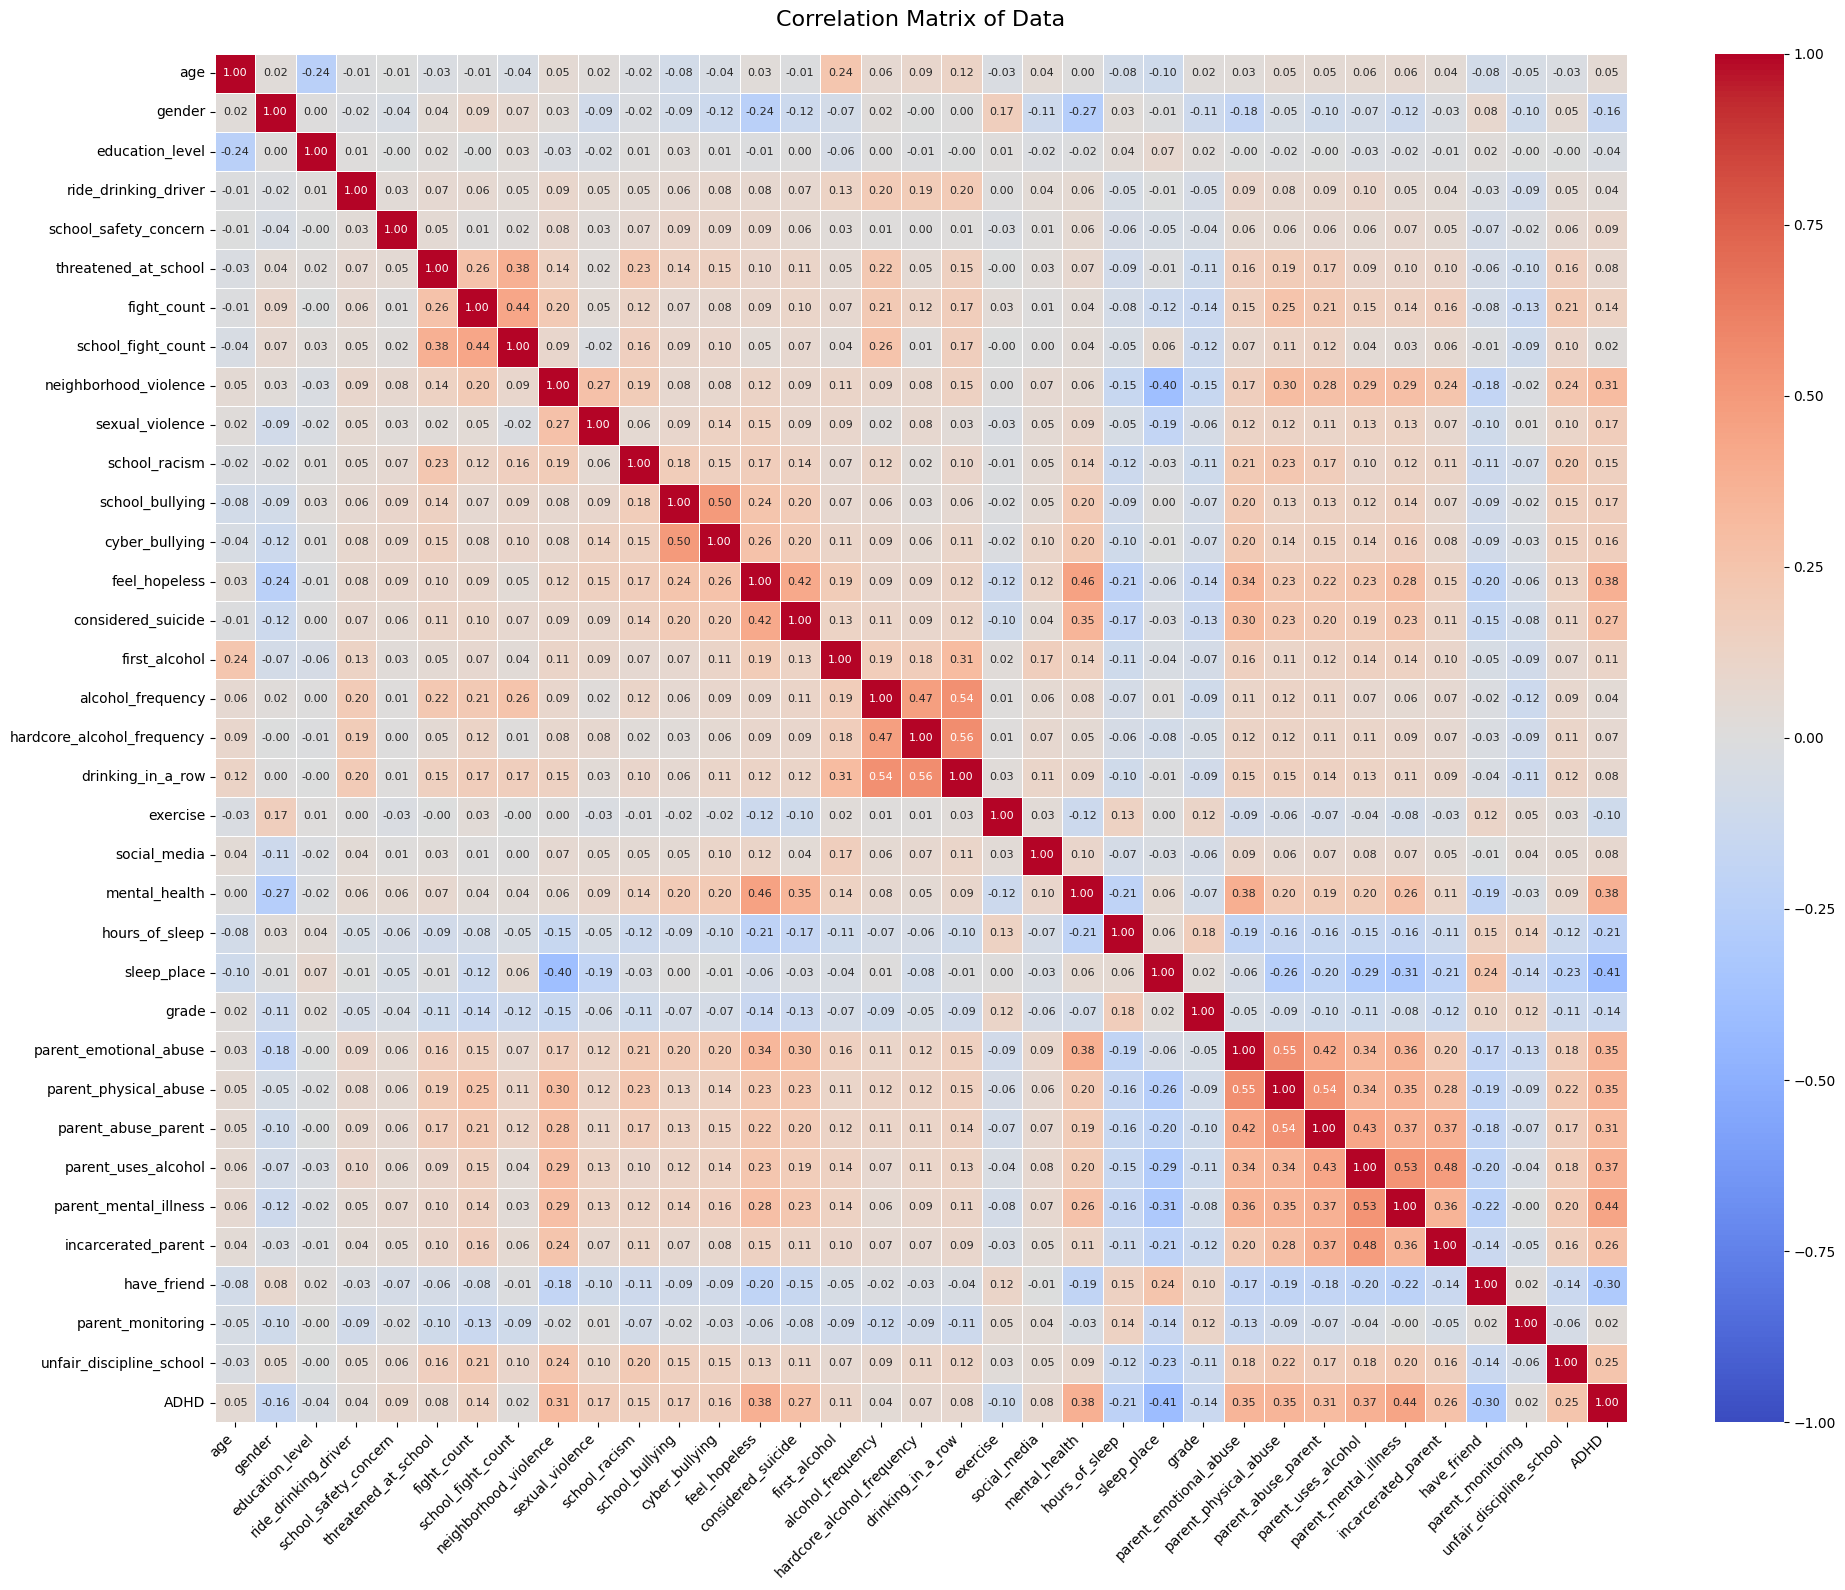

In [6]:
from sklearn.preprocessing import LabelEncoder


df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(20, 16))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f",
            annot_kws={"size": 8},
            linewidths=0.5,
            vmin=-1, vmax=1
            )   

plt.title('Correlation Matrix of Data', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
le = LabelEncoder()
df['grade_encoded'] = le.fit_transform(df['grade'])

X = df.drop(columns=['grade', 'grade_encoded'])
y = df['grade_encoded']

#  Column ที่เป็น String 
cat_features = ['gender', 'education_level', 'considered_suicide', 'sleep_place']

# แปลงประเภทข้อมูลให้เป็น category
for col in cat_features:
    X[col] = X[col].astype('category')

# แบ่งข้อมูลเป็น Train/Test -> 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# เทรนโมเดล
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softprob',
    enable_categorical=True,  # เอาไว้ให้ใช้ category ที่แปลงมา
    tree_method='hist',
    random_state=42
)

model.fit(X_train, y_train)

# ทดสอบโมเดล
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))

Accuracy: 0.4438
              precision    recall  f1-score   support

         0.0       0.32      0.12      0.18        90
         1.0       0.09      0.02      0.03       154
         2.0       0.35      0.15      0.21       565
         3.0       0.38      0.32      0.35      1052
         4.0       0.49      0.75      0.60      1278

    accuracy                           0.44      3139
   macro avg       0.33      0.27      0.27      3139
weighted avg       0.40      0.44      0.40      3139



C:\Users\Norawit\AppData\Local\Temp\ipykernel_28580\1264057573.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


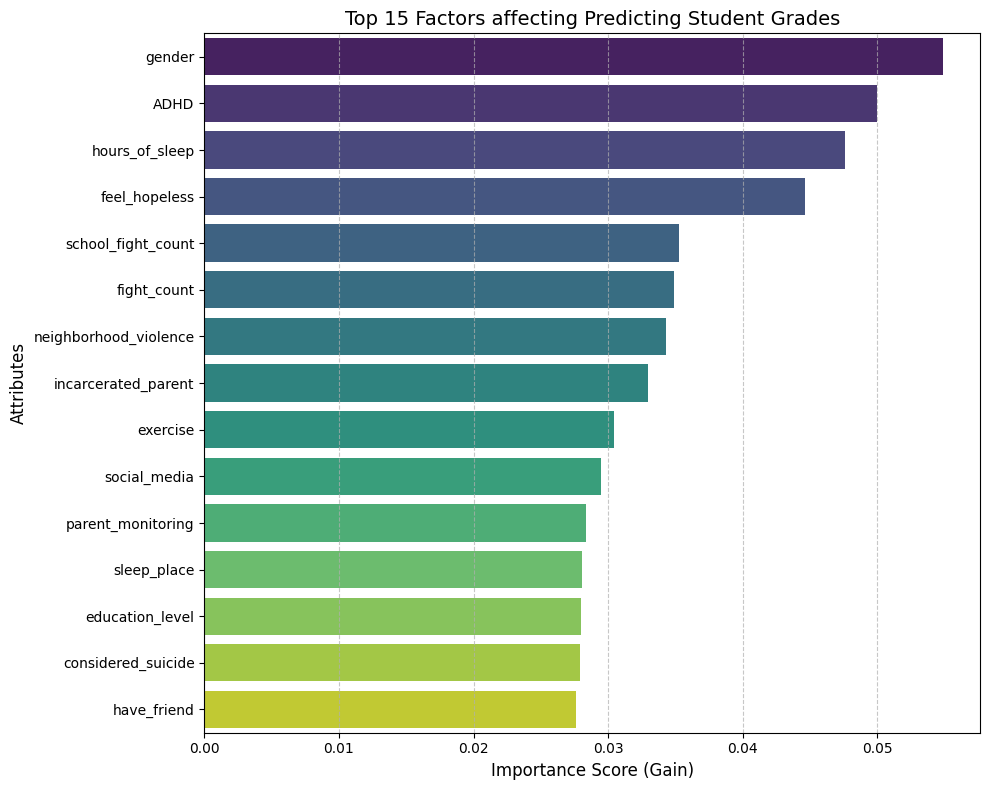

In [ ]:
# ดึงค่าความสำคัญของ Feature ออกมา
importances = model.feature_importances_
feature_names = X.columns

# สร้าง DataFrame แล้วเอาไป plot
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# วาดกราฟ (แสดง Top 15 ปัจจัยหลัก)
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(15),
    palette='viridis'
)

plt.title('Top 15 Factors affecting Predicting Student Grades', fontsize=14)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Attributes', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()